<a href="https://colab.research.google.com/github/sarthakchauhan2307/ObjectDetection/blob/main/ObjectDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection Using **CNN**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F     # F = activation functions, losses

import torchvision                    # torchvision = image datasets & tools
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
print(device)

cuda


In [4]:
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [5]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],  # Mean for R, G, B channels
        std=[0.2470, 0.2435, 0.2616]
    )
])

In [6]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]


In [7]:
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,          # False = test set
    download=True,
    transform=basic_transform
)

In [8]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

In [9]:
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=2
)

In [10]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [11]:
print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")

Training batches: 782
Test batches:     157


In [12]:
image,labels= next(iter(train_loader))

In [13]:
print("Batch shape:", image.shape)

Batch shape: torch.Size([64, 3, 32, 32])


In [14]:
print("Labels shape:", labels.shape)

Labels shape: torch.Size([64])


In [15]:
print("Pixel value range:", image.min().item(), "to", image.max().item())

Pixel value range: -1.9894737005233765 to 2.12648868560791


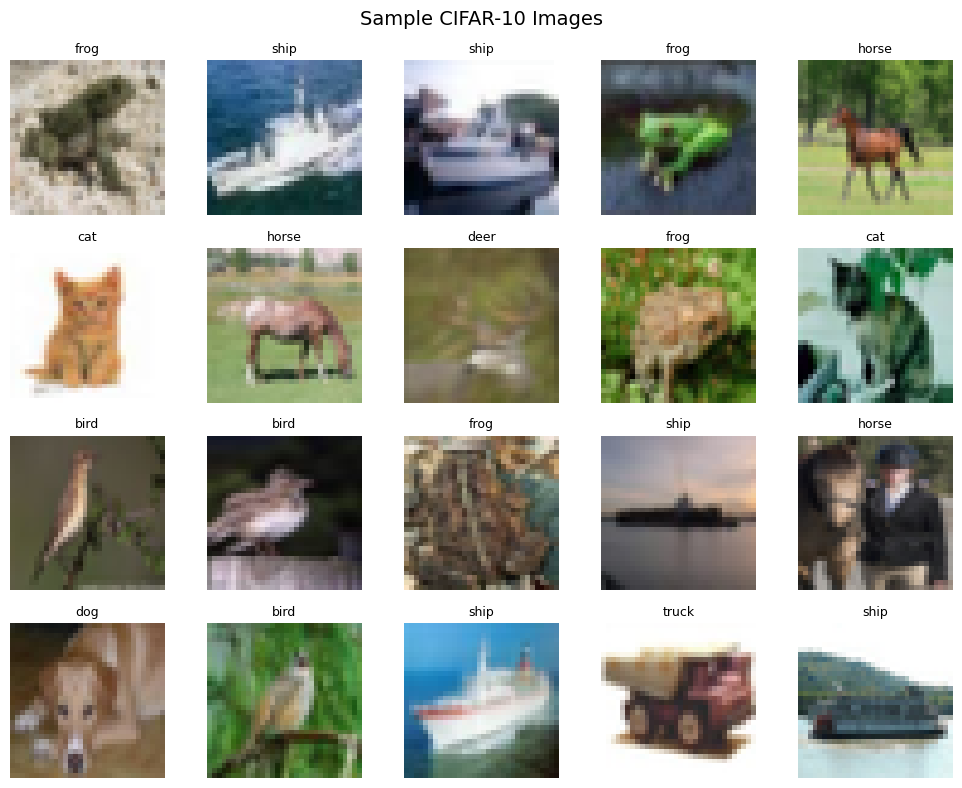

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle('Sample CIFAR-10 Images', fontsize=14)

for i, ax in enumerate(axes.flatten()):
    img = image[i]              # Shape: (3, 32, 32)

    # Un-normalize the image for display
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img = img * std + mean

    # PyTorch = (C,H,W), matplotlib needs (H,W,C) → permute
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32,padding=4),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

In [18]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

In [19]:
train_dataset = torchvision.datasets.CIFAR10(
    './data', train=True,  download=False, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    './data', train=False, download=False, transform=test_transform)


In [20]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print("Data augmentation applied! ")

Data augmentation applied! 


In [28]:
class CIFAR10_CNN(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    )
    self.bn1 = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.bn2 =  nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.pool = nn.MaxPool2d(2,2)

    self.dropout = nn.Dropout(p=0.4)

    self.fc1 = nn.Linear(128 * 4 * 4, 512)  # 2048 → 512
    self.fc2 = nn.Linear(512, 10)



  def forward(self,x):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))

    x = self.pool(F.relu(self.bn2(self.conv2(x))))

    x = self.pool(F.relu(self.bn3(self.conv3(x))))

    x = x.view(x.size(0),-1)

    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)

    return x


model = CIFAR10_CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CIFAR10_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

Total parameters: 1,147,914


In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epoch = 25
train_loss, train_acc = [], []

for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = output.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epoch}]  "
          f"Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.1f}%")

Epoch [ 1/25]  Loss: 1.5322  Acc: 43.5%
Epoch [ 2/25]  Loss: 1.1904  Acc: 57.1%
Epoch [ 3/25]  Loss: 1.0509  Acc: 62.8%
Epoch [ 4/25]  Loss: 0.9632  Acc: 66.2%
Epoch [ 5/25]  Loss: 0.8988  Acc: 68.2%
Epoch [ 6/25]  Loss: 0.8580  Acc: 70.1%
Epoch [ 7/25]  Loss: 0.8238  Acc: 71.1%
Epoch [ 8/25]  Loss: 0.7859  Acc: 72.8%
Epoch [ 9/25]  Loss: 0.7556  Acc: 73.8%
Epoch [10/25]  Loss: 0.7354  Acc: 74.6%
Epoch [11/25]  Loss: 0.6621  Acc: 77.0%
Epoch [12/25]  Loss: 0.6345  Acc: 78.1%
Epoch [13/25]  Loss: 0.6244  Acc: 78.6%
Epoch [14/25]  Loss: 0.6125  Acc: 78.8%
Epoch [15/25]  Loss: 0.5985  Acc: 79.3%
Epoch [16/25]  Loss: 0.5878  Acc: 79.7%
Epoch [17/25]  Loss: 0.5859  Acc: 79.9%
Epoch [18/25]  Loss: 0.5704  Acc: 80.5%
Epoch [19/25]  Loss: 0.5621  Acc: 80.8%
Epoch [20/25]  Loss: 0.5571  Acc: 80.6%
Epoch [21/25]  Loss: 0.5208  Acc: 81.8%
Epoch [22/25]  Loss: 0.5125  Acc: 82.3%
Epoch [23/25]  Loss: 0.5044  Acc: 82.5%
Epoch [24/25]  Loss: 0.5043  Acc: 82.8%
Epoch [25/25]  Loss: 0.5006  Acc: 82.7%


In [31]:
# model evalution
model.eval()

test_correct =0
test_total =0
all_pred=[]
all_label =[]

with torch.no_grad():

  for image,labels in test_loader:
    image = image.to(device)
    labels = labels.to(device)
    output = model(image)
    _,predicted = output.max(1)

    test_total += labels.size(0)
    test_correct += predicted.eq(labels).sum().item()
    all_pred.extend(predicted.cpu().numpy())
    all_label.extend(labels.cpu().numpy())


test_acc = 100*test_correct/test_total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 83.83%


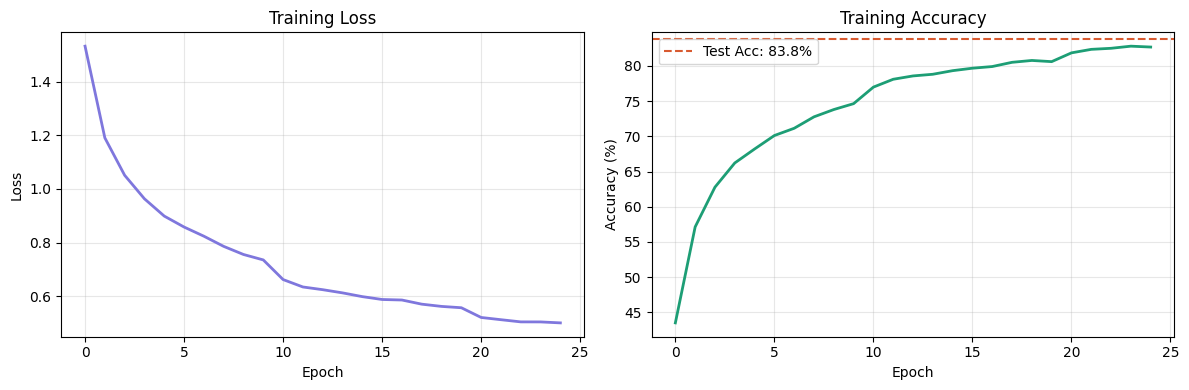

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss, color='#7F77DD', linewidth=2)
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss'); ax1.grid(True, alpha=0.3)

ax2.plot(train_acc, color='#1D9E75', linewidth=2)
ax2.axhline(y=test_acc, color='#D85A30', linestyle='--',
            label=f'Test Acc: {test_acc:.1f}%')
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_label, all_pred)

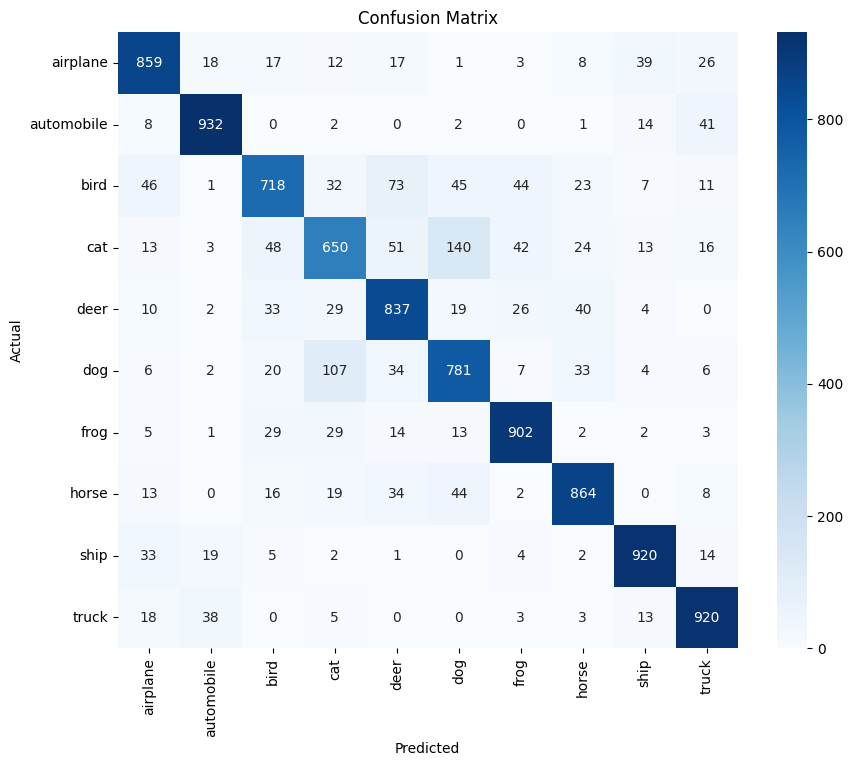

In [37]:
import seaborn as sns
plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,           # show numbers
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
from sklearn.metrics import classification_report
report = classification_report(all_label, all_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.85      0.86      0.85      1000
  automobile       0.92      0.93      0.92      1000
        bird       0.81      0.72      0.76      1000
         cat       0.73      0.65      0.69      1000
        deer       0.79      0.84      0.81      1000
         dog       0.75      0.78      0.76      1000
        frog       0.87      0.90      0.89      1000
       horse       0.86      0.86      0.86      1000
        ship       0.91      0.92      0.91      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



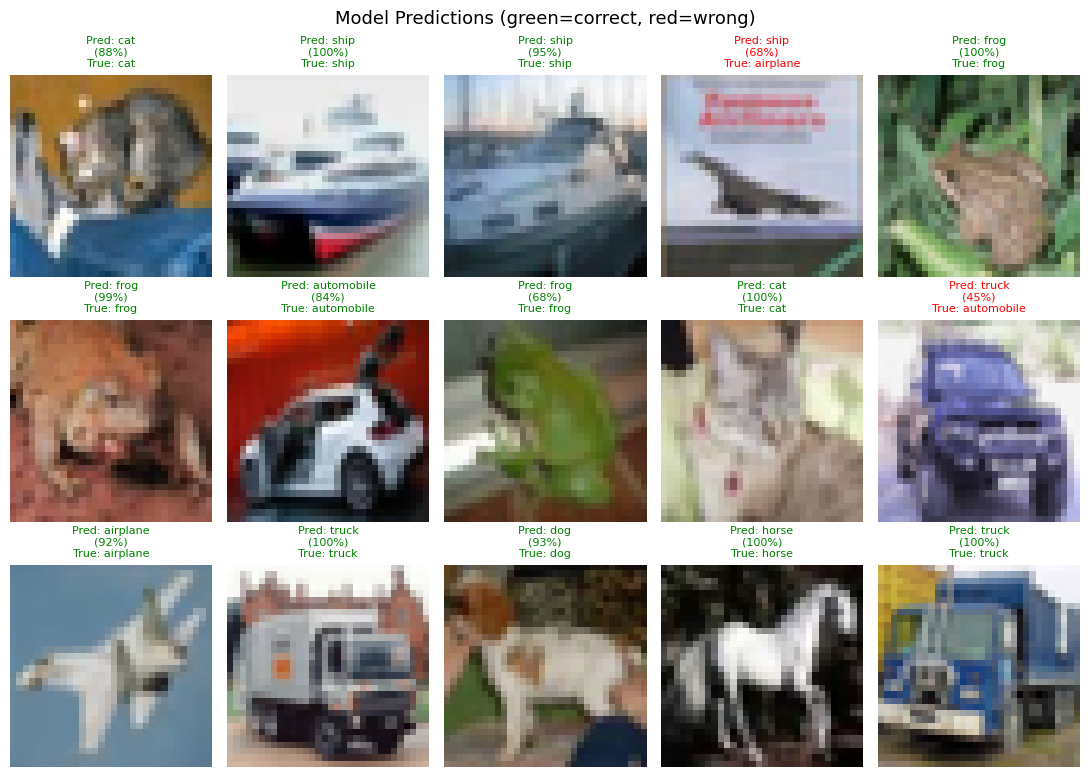

In [42]:
model.eval()
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    probs   = torch.nn.functional.softmax(outputs, dim=1)   # → probabilities
    _, preds = probs.max(1)

fig, axes = plt.subplots(3, 5, figsize=(11, 8))
fig.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    mean = torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1)
    img  = (images[i] * std + mean).permute(1,2,0).numpy()
    img  = np.clip(img, 0, 1)
    ax.imshow(img)

    pred_name  = class_names[preds[i]]
    true_name  = class_names[labels[i]]
    confidence = probs[i][preds[i]].item() * 100
    correct    = preds[i] == labels[i]

    color = 'green' if correct else 'red'
    ax.set_title(f"Pred: {pred_name}\n({confidence:.0f}%)\nTrue: {true_name}",
                 fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [41]:
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print("Model saved to cifar10_cnn.pth ✓")

# ── Reload the model later (no need to retrain) ──────────────────
loaded_model = CIFAR10_CNN().to(device)
loaded_model.load_state_dict(torch.load('cifar10_cnn.pth'))
loaded_model.eval()
print("Model reloaded successfully ✓")

# ── Predict a single image ────────────────────────────────────────
def predict_one(model, image_tensor):
    model.eval()
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)  # Add batch dim
        out = model(img)
        prob = F.softmax(out, dim=1)
        conf, pred = prob.max(1)
        return class_names[pred.item()], conf.item() * 100

# Test it on first test image
pred_class, confidence = predict_one(loaded_model, test_dataset[0][0])
true_class = class_names[test_dataset[0][1]]
print(f"Predicted: {pred_class} ({confidence:.1f}%)")
print(f"Actual:    {true_class}")

Model saved to cifar10_cnn.pth ✓
Model reloaded successfully ✓
Predicted: cat (88.2%)
Actual:    cat
